In [ ]:
import torch
from torch import nn
from torchvision import datasets, transforms
import numpy as np

### Traditional GAN (MLP)

### Load MNIST dataset

In [ ]:
image_size = 32
transform = transforms.Compose(
    [
        transforms.Resize((image_size, image_size)),
        transforms.ToTensor(),
        transforms.Normalize(mean=[0.5], std=[0.5]),
    ]
)

# download dataset from API and apply transformation
train_set = datasets.MNIST(root='./mnist_data', train=True, download=False, transform=transform)
test_set = datasets.MNIST(root='./mnist_data', train=False, download=False, transform=transform)

# Load data by Batch_Size
data_loader = torch.utils.data.DataLoader(train_set, batch_size=64, shuffle=True)

In [58]:
samples = iter(data_loader)
imgs, img_labels = next(samples)

tensor(2)
torch.Size([1, 32, 32])


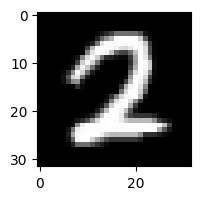

In [59]:
import matplotlib.pyplot as plt

# Visualize the first image in the batch
print(img_labels[0])
print(imgs[0].shape)
plt.figure(figsize=(2, 2))  # Set figure size to 200x200 pixels (assuming 100 DPI)
plt.imshow(imgs[0].squeeze(), cmap='gray')
plt.show()

In [60]:
imgs.shape[0]

64

## Define Parameters and Inputs
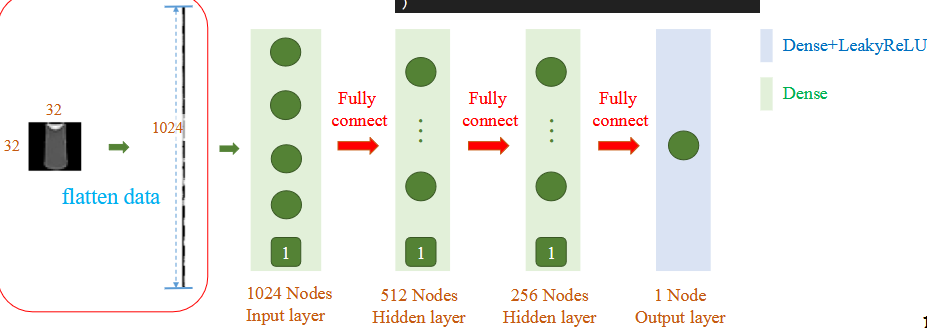

In [61]:
# define GAN input noise
latent_dim = 512
img_size = 32
channels = 1
img_shape = (channels, img_size, img_size)
flat_size = int(np.prod(img_shape))  # 784

### Create MLP GAN
#### Generator

In [62]:
class Generator(nn.Module):
    def __init__(self) -> None:
        super().__init__()
        self.model = nn.Sequential(
            nn.Linear(latent_dim, 256),
            nn.BatchNorm1d(256,),
            nn.LeakyReLU(0.2, inplace=True),

            nn.Linear(256, 512),
            nn.BatchNorm1d(512,),
            nn.LeakyReLU(0.2, inplace=True),

            nn.Linear(512, 1024),
            nn.BatchNorm1d(1024,),
            nn.LeakyReLU(0.2, inplace=True),

            nn.Linear(1024, flat_size), # return exactly original image shape
            nn.Tanh()
        )

    def forward(self, x):
        # learn feature
        x = self.model(x)
        # reshape back to 28x28
        x = x.view(x.shape[0], *img_shape) # batch_size, 1 channels, 28 height, 28 width
        return x

generator = Generator()

##### Discriminator

In [63]:
import numpy as np
print(imgs[0].shape)
print(imgs[0].flatten().shape, 512)
print(int(np.prod(imgs[0].shape)))
print(imgs[0].flatten().shape[0])


torch.Size([1, 32, 32])
torch.Size([1024]) 512
1024
1024


In [64]:
class Discriminator(nn.Module):
    def __init__(self) -> None:
        super().__init__()
        self.model = nn.Sequential(
            nn.Linear(flat_size, 512), # take the first img in batch and get its flatten().shape dim value using [0]
            nn.LeakyReLU(0.2, inplace=True),

            nn.Linear(512, 256),
            nn.LeakyReLU(0.2, inplace=True),

            nn.Linear(256, 1),
            nn.Sigmoid(), # fake image probability [0,1]
        )

    def forward(self, x):
        # x = torch.flatten(x, start_dim=1) # flatten every dim except for the firsts ie. batch
        x = x.view(x.size(0), -1)
        x = self.model(x)
        return x


discriminator = Discriminator()

### Training

In [65]:
print(torch.flatten(imgs[0], start_dim=1).shape)
print(imgs[0].view(imgs[0].size(0), -1).shape)

torch.Size([1, 1024])
torch.Size([1, 1024])


In [66]:
criterion = nn.BCELoss() # binary cross entropy
real_labels = torch.ones(imgs.shape[0], 1)
fake_labels = torch.zeros(imgs.shape[0], 1) # row x col
z = torch.randn((imgs.shape[0], latent_dim))
print('z_shape:', z.shape)

gen_imgs = generator(z)
print(gen_imgs.shape)
real_loss = criterion(discriminator(imgs), real_labels)
fake_loss = criterion(discriminator(gen_imgs.detach()), fake_labels) # apply detach to stop gradient update
D_loss = (real_loss + fake_loss) / 2
print('Discriminator Loss:', D_loss)

z_shape: torch.Size([64, 512])
torch.Size([64, 1, 32, 32])
Discriminator Loss: tensor(0.6778, grad_fn=<DivBackward0>)


In [67]:
g_loss = criterion(discriminator(gen_imgs), real_labels)
g_loss

tensor(0.7379, grad_fn=<BinaryCrossEntropyBackward0>)

### Batch Training
Note_1: Loss (criterion) calculated during Forward Pass

Note_2: Optimizer like Adam, GD, SGD update during Backward Pass (backpropagration). 

**Training Flow** 
1. Define Loss and Optimizer function for Generator and Discriminator
2. Load Data: load batch of image from dataloader 
3. Train Generator 
    + define flatten noise vector $z$
    + generate image -> assign as $img\_gen$ var
    + loss: G loss is depend on D -> loss(D(G(z)), real_label) - gen img always see as real image.
    + update using the optimizer (search for how gradient update in pytorch) 
4. Train Discriminator (Interchangebly)
    + L_real_img: loss(discriminator($img\_gen$), fake_label)
    + L_real_img: loss(discriminator(real_img), real_label)
    + calc average loss (fake+real)/2
    + update the discriminator

In [68]:
#? check how many var within data_loader
batch = next(iter(data_loader))
print(len(batch))  # Outputs the number of variables
print(type(batch)) # Often <class 'list'> or <class 'tuple'>

2
<class 'list'>


In [69]:
# Extract batch of image from Dataloader
from torchvision.utils import save_image
import os

EPOCHS = 50
hist = {
    'g_losses' : [],
    'd_losses' : []
}
save_interval = 10
os.makedirs('gan_images', exist_ok=True)

In [70]:
device = 'cuda' if torch.cuda.is_available() else 'cpu'
generator = Generator().to(device)
discriminator = Discriminator().to(device)

loss_func = nn.BCELoss()
optimizer_G = torch.optim.Adam(generator.parameters(), lr=0.0001)
optimizer_D = torch.optim.Adam(discriminator.parameters(), lr=0.0002)
print(device)

for epoch in range(EPOCHS):
    running_g_loss = 0.0
    running_d_loss = 0.0

    for i, (img_batch, label_batch) in enumerate(data_loader):
        real_labels = torch.ones(img_batch.shape[0], 1).to(device) # (batch_size, 1) - True labels for each image
        fake_labels = torch.zeros(img_batch.shape[0], 1).to(device)

        # add img_batch to device
        img_batch, label_batch = img_batch.to(device), label_batch


        #! train Generator
        optimizer_G.zero_grad()
        z = torch.randn((img_batch.shape[0], latent_dim)).to(device)

        #* forward pass
        gen_imgs = generator(z) # [64, 1, 28, 28]

        # g_loss = loss_func(discriminator(gen_imgs), real_labels)
        g_loss = loss_func(discriminator(gen_imgs), real_labels)

        g_loss.backward() #* backward pass
        optimizer_G.step() #* update weights

        #! train Discriminator
        optimizer_D.zero_grad()
        real_loss = loss_func(discriminator(img_batch), real_labels)
        fake_loss = loss_func(discriminator(gen_imgs.detach()), fake_labels)
        d_loss = (real_loss + fake_loss) / 2

        d_loss.backward()
        optimizer_D.step()

        running_g_loss+=g_loss.item()
        running_d_loss+=d_loss.item()

    epoch_g_loss = running_g_loss/len(data_loader)
    epoch_d_loss = running_d_loss/len(data_loader)

    hist['g_losses'].append(epoch_g_loss)
    hist['d_losses'].append(epoch_d_loss)

    print(f"Epoch [{epoch + 1}/{EPOCHS}], Train G Loss: {epoch_g_loss:.4f}, Train D Loss: {epoch_d_loss:.4f}")

    if epoch % save_interval == 0:
        save_image(gen_imgs.data[:25], f"gan_images/epoch_{epoch}.png", nrow=5, normalize=True)

cuda
Epoch [1/50], Train G Loss: 10.6039, Train D Loss: 0.0450
Epoch [2/50], Train G Loss: 6.5134, Train D Loss: 0.0526
Epoch [3/50], Train G Loss: 7.2837, Train D Loss: 0.0347
Epoch [4/50], Train G Loss: 6.8772, Train D Loss: 0.0503
Epoch [5/50], Train G Loss: 7.9034, Train D Loss: 0.0555
Epoch [6/50], Train G Loss: 6.9631, Train D Loss: 0.0729
Epoch [7/50], Train G Loss: 6.2461, Train D Loss: 0.0709
Epoch [8/50], Train G Loss: 5.8141, Train D Loss: 0.1012
Epoch [9/50], Train G Loss: 5.8546, Train D Loss: 0.0943
Epoch [10/50], Train G Loss: 5.8652, Train D Loss: 0.0990
Epoch [11/50], Train G Loss: 5.9788, Train D Loss: 0.0996
Epoch [12/50], Train G Loss: 5.3391, Train D Loss: 0.1155
Epoch [13/50], Train G Loss: 5.3103, Train D Loss: 0.1038
Epoch [14/50], Train G Loss: 5.4343, Train D Loss: 0.1193
Epoch [15/50], Train G Loss: 4.9105, Train D Loss: 0.1322
Epoch [16/50], Train G Loss: 5.0910, Train D Loss: 0.1276
Epoch [17/50], Train G Loss: 5.0953, Train D Loss: 0.1304
Epoch [18/50], Tr

KeyboardInterrupt: 

In [ ]:
import matplotlib.pyplot as plt

def visualize_gan(hist):
    plt.figure(figsize=(10, 5))
    plt.plot(hist['d_losses'], label='Discriminator Loss')
    plt.plot(hist['g_losses'], label='Generator Loss')  # Also fix the label - was 'Discriminator Loss'
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.title('GAN Losses')
    plt.legend()
    plt.show()

visualize_gan(hist)

## Traning Interchangebly

In [ ]:
class Generator(nn.Module):
    def __init__(self) -> None:
        super().__init__()
        self.model = nn.Sequential(
            nn.Linear(latent_dim, 256),
            nn.BatchNorm1d(256,),
            nn.LeakyReLU(0.2, inplace=True),

            nn.Linear(256, 512),
            nn.BatchNorm1d(512,),
            nn.LeakyReLU(0.2, inplace=True),

            nn.Linear(512, 1024),
            nn.BatchNorm1d(1024,),
            nn.LeakyReLU(0.2, inplace=True),

            nn.Linear(1024, flat_size), # return exactly original image shape
            nn.Tanh()
        )

    def forward(self, x):
        # learn feature
        x = self.model(x)
        # reshape back to 28x28
        x = x.view(x.shape[0], *img_shape) # batch_size, 1 channels, 28 height, 28 width
        return x

generator = Generator()

In [ ]:
class Discriminator(nn.Module):
    def __init__(self) -> None:
        super().__init__()
        self.model = nn.Sequential(
            nn.Linear(flat_size, 512), # take the first img in batch and get its flatten().shape dim value using [0]
            nn.LeakyReLU(0.2, inplace=True),

            nn.Linear(512, 256),
            nn.LeakyReLU(0.2, inplace=True),

            nn.Linear(256, 1),
            # nn.Sigmoid(), # fake image probability [0,1]
        )

    def forward(self, x):
        # x = torch.flatten(x, start_dim=1) # flatten every dim except for the firsts ie. batch
        x = x.view(x.size(0), -1)
        x = self.model(x)
        return x


discriminator = Discriminator()

In [ ]:
device = 'cuda' if torch.cuda.is_available() else 'cpu'
generator = Generator().to(device)
discriminator = Discriminator().to(device)
EPOCHS = 200

loss_func = nn.BCELoss()
optimizer_G = torch.optim.RMSprop(generator.parameters(), lr=0.00005)
optimizer_D = torch.optim.RMSprop(discriminator.parameters(), lr=0.00005)
save_interval = 1

print(device)

def weights_init(m):
    if isinstance(m, (nn.Conv2d, nn.ConvTranspose2d)):
        nn.init.normal_(m.weight.data, 0.0, 0.02)
    elif isinstance(m, nn.BatchNorm2d):
        nn.init.normal_(m.weight.data, 1.0, 0.02)
        nn.init.constant_(m.bias.data, 0)

generator.apply(weights_init)
discriminator.apply(weights_init);

In [ ]:
L = len(data_loader)
for epoch in range(EPOCHS):
    running_g_loss = 0.0
    running_d_loss = 0.0

    for i, (img_batch, label_batch) in enumerate(data_loader):
        real_labels = torch.ones(img_batch.shape[0], 1).to(device) # (batch_size, 1) - True labels for each image
        fake_labels = torch.zeros(img_batch.shape[0], 1).to(device)

        # add img_batch to device
        img_batch, label_batch = img_batch.to(device), label_batch


        #! TRAIN Generator
        optimizer_G.zero_grad()
        z = torch.randn((img_batch.shape[0], latent_dim)).to(device)

        #* forward pass
        gen_imgs = generator(z) # [64, 1, 28, 28]
        g_loss = -torch.mean(discriminator(gen_imgs))
        # g_loss = loss_func(discriminator(gen_imgs), real_labels)

        g_loss.backward() #* backward pass
        optimizer_G.step() #* update weights


        #! TRAIN Discriminator => loss_C = -(torch.mean(loss_func(real_images)) - torch.mean(loss_func(fake_images)))
        optimizer_D.zero_grad()
        # real_loss = loss_func(discriminator(img_batch), real_labels)
        # fake_loss = loss_func(discriminator(gen_imgs.detach()), fake_labels)

        # Wasserstain Critic Loss
        d_loss = -(torch.mean(discriminator(img_batch)) - torch.mean(discriminator(gen_imgs.detach())))

        d_loss.backward()
        optimizer_D.step()

        # satisfy the "1-Lipschitz" mathematical constraint
        #? Weight CLIPPING to a small range (like [-0.01, 0.01])
        for p in discriminator.parameters():
            p.data.clamp_(-0.01, 0.01)


        running_g_loss+=g_loss.item()
        running_d_loss+=d_loss.item()

    epoch_g_loss = running_g_loss/L
    epoch_d_loss = running_d_loss/L

    hist['g_losses'].append(epoch_g_loss)
    hist['d_losses'].append(epoch_d_loss)

    print(f"Epoch [{epoch + 1}/{EPOCHS}], Train G Loss: {epoch_g_loss:.4f}, Train D Loss: {epoch_d_loss:.4f}")

    if epoch % save_interval == 0:
        save_image(gen_imgs.data[:25], f"gan_images/epoch_{epoch}.png", nrow=5, normalize=True)

In [ ]:
def visualize_wgan(hist):
    plt.figure(figsize=(10, 5))

    # In WGAN, the Discriminator is referred to as the Critic
    plt.plot(hist['d_losses'], label='Critic (D) Loss', color='blue', alpha=0.8)
    plt.plot(hist['g_losses'], label='Generator (G) Loss', color='orange', alpha=0.8)

    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.title('Wasserstein GAN (WGAN) Losses')
    plt.grid(True, linestyle='--', alpha=0.6) # Added grid to easily see negative values
    plt.legend()
    plt.show()

visualize_wgan(hist)